# 13. Interpretabilnost i objašnjivost modela

## Složeni modeli i interpretabilnost

Složeni modeli su često neophodni, ali imaju **nisku interpretabilnost**. Postoje dva
osnovna pristupa za njeno unapređenje:

**1. Smanjenje složenosti modela**
- korišćenje jednostavnijih modela (linearni modeli, plitka stabla)
- lakši za razumevanje
- **često dovodi do smanjenja tačnosti**

**2. Model-agnostičke metode interpretacije**
- **zadržavamo** složene i tačne modele
- primenjujemo **post-hoc** metode za objašnjavanje odluka
- mogu se primeniti na bilo koji model (black-box)

> **Post-hoc metode** objašnjavaju odluke modela **nakon** što je model već istreniran.
> One ne menjaju model, već analiziraju odnos između ulaza i izlaza.

> **Cilj interpretabilnosti nije da pojednostavimo stvarnost po svaku cenu, već da razumemo
> odluke modela bez žrtvovanja performansi.**

## Podela metoda interpretacije

| | **model-agnostičke** | **model-specifične** |
|---|---|---|
| primenljivost | **bilo koji** model | zavise od strukture modela |
| pristup | tretiraju model kao **crnu kutiju**, koriste samo ulaze i izlaze | koriste unutrašnjost modela |
| primeri | **SHAP**, **LIME**, **PDP**, **ICE** | koeficijenti linearne regresije, struktura stabla, `feature_importances_` kod RF, gradijenti kod mreža (saliency maps) |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from xgboost import XGBClassifier

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42

bc = load_breast_cancer(as_frame=True)
X, y = bc.data, bc.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RS, stratify=y)
print(f"Podaci: {X.shape[0]} uzoraka x {X.shape[1]} obelezja")

Podaci: 569 uzoraka x 30 obelezja


## Model-specifične metode

Najjednostavniji slučaj — model koji je sam po sebi interpretabilan.

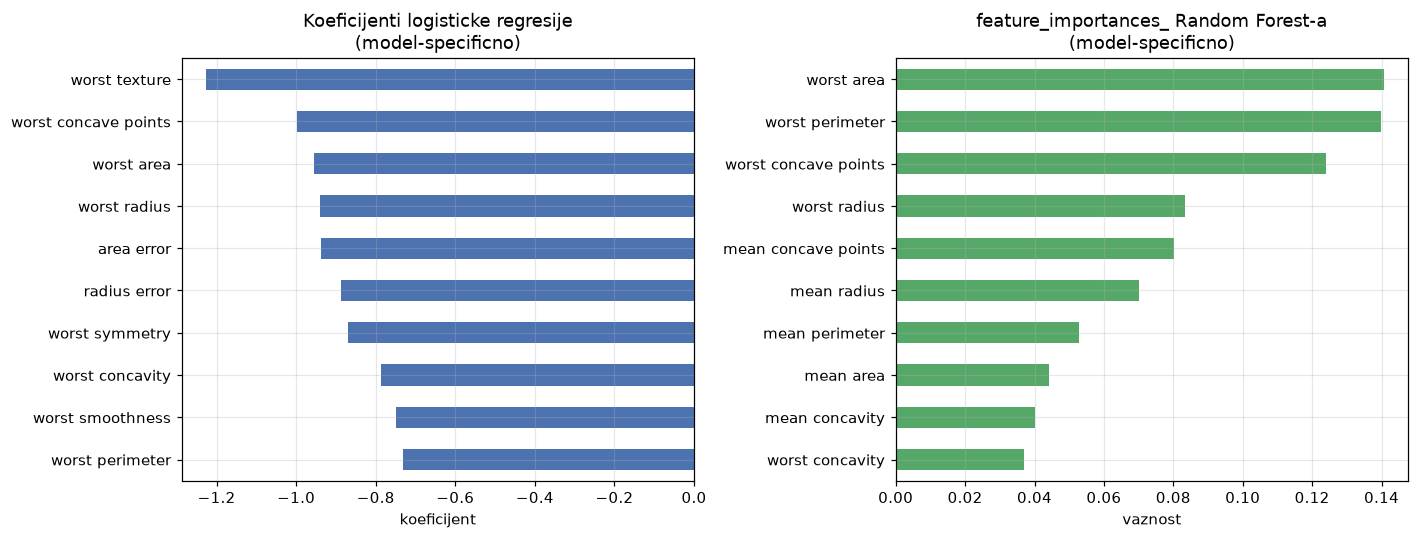

In [2]:
# 1. koeficijenti linearnog modela
log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xtr, ytr)
koef = pd.Series(log.named_steps["logisticregression"].coef_[0], index=X.columns)

# 2. feature_importances_ kod Random Forest-a
rf = RandomForestClassifier(n_estimators=300, random_state=RS, n_jobs=-1).fit(Xtr, ytr)
vazn_rf = pd.Series(rf.feature_importances_, index=X.columns)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
k = koef.sort_values(key=abs, ascending=False).head(10)[::-1]
k.plot.barh(ax=ax[0], color=["#C44E52" if v > 0 else "#4C72B0" for v in k])
ax[0].set_title("Koeficijenti logisticke regresije\n(model-specificno)")
ax[0].set_xlabel("koeficijent")

vazn_rf.sort_values(ascending=False).head(10)[::-1].plot.barh(ax=ax[1], color="#55A868")
ax[1].set_title("feature_importances_ Random Forest-a\n(model-specificno)")
ax[1].set_xlabel("vaznost")
plt.tight_layout(); plt.show()

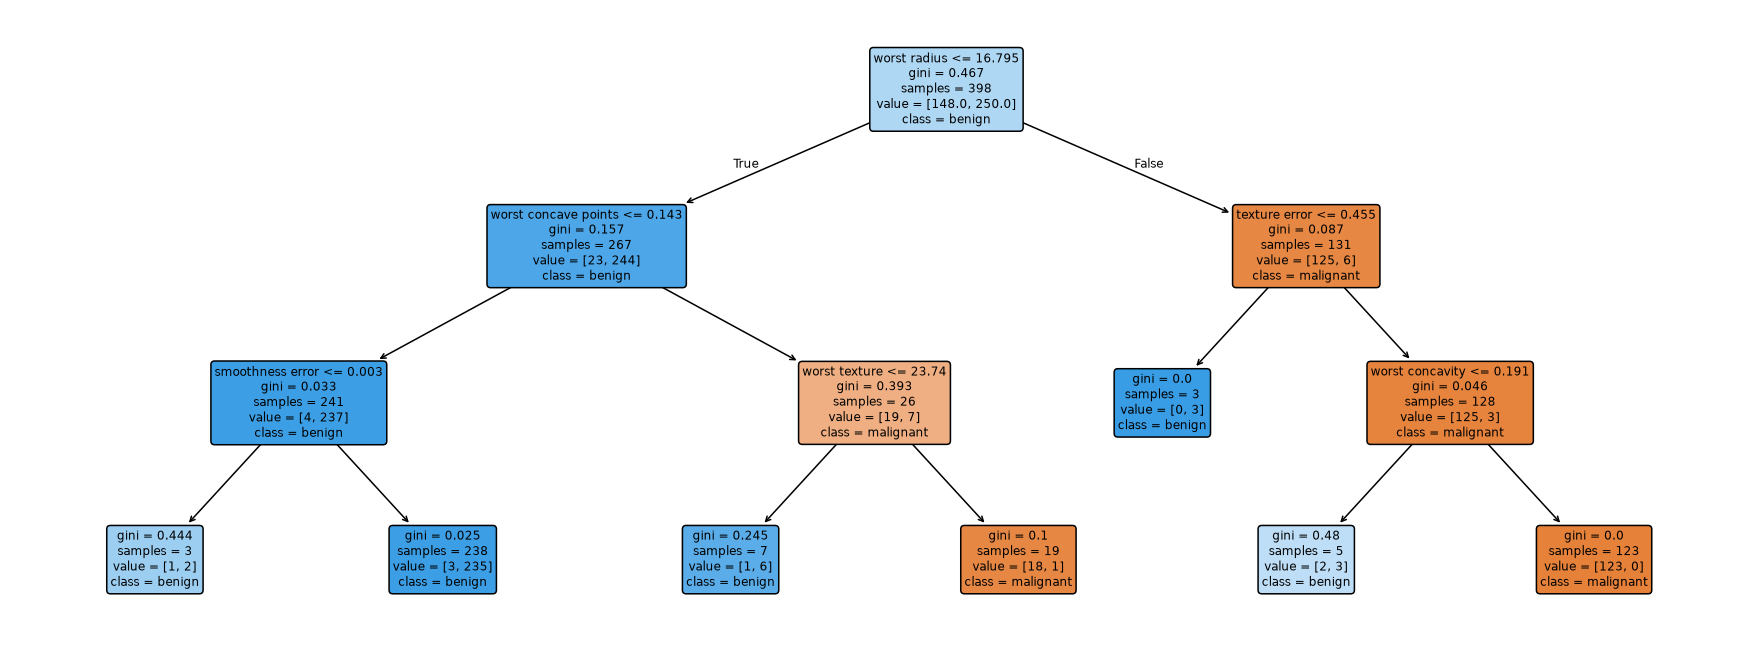

Put od korena do lista je jedno if-then pravilo. Ovo je najcitljiviji oblik modela.


In [3]:
# 3. struktura stabla — najdirektnija interpretacija
st = DecisionTreeClassifier(max_depth=3, random_state=RS).fit(Xtr, ytr)
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(st, feature_names=X.columns, class_names=bc.target_names,
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.tight_layout(); plt.show()
print("Put od korena do lista je jedno if-then pravilo. Ovo je najcitljiviji oblik modela.")

## Model-agnostičke metode

### Permutaciona važnost

Meri koliko **padne performansa** kada se vrednosti jednog obeležja nasumično promešaju.
Ako mešanje ne menja rezultat, obeležje nije važno.

Radi nad **bilo kojim** modelom, jer koristi samo ulaze i izlaze.

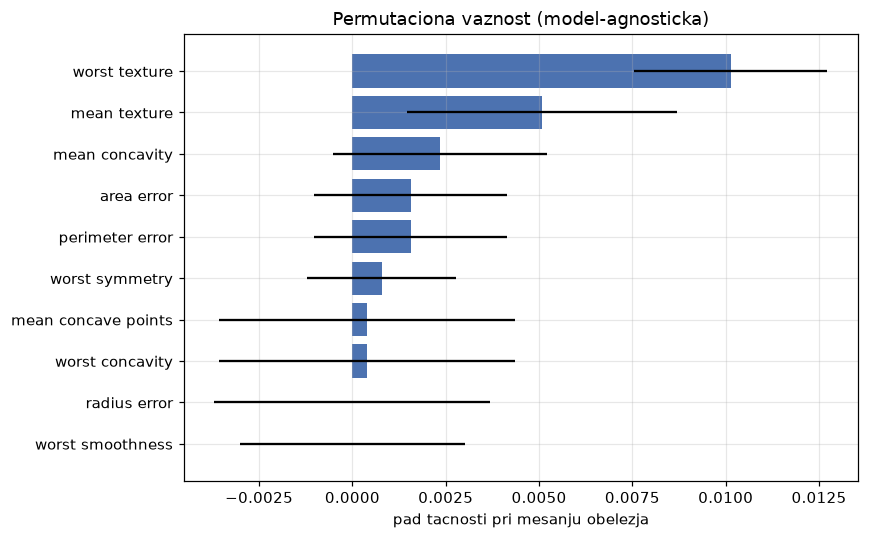

In [4]:
pi = permutation_importance(rf, Xte, yte, n_repeats=15, random_state=RS,
                            scoring="accuracy", n_jobs=-1)
pi_s = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
top = pi_s.head(10)[::-1]
ax.barh(top.index, top.values,
        xerr=[pi.importances_std[list(X.columns).index(i)] for i in top.index],
        color="#4C72B0")
ax.set_xlabel("pad tacnosti pri mesanju obelezja")
ax.set_title("Permutaciona vaznost (model-agnosticka)")
plt.tight_layout(); plt.show()

## Shapley vrednosti (SHAP)

**SHAP** je model-agnostička, post-hoc metoda koja objašnjava **doprinos svakog atributa
konačnoj predikciji**, posmatrajući model kao crnu kutiju.

> SHAP prvenstveno objašnjava **pojedinačne predikcije**, dok se **globalna važnost**
> dobija **agregacijom** tih objašnjenja.

### Poreklo — teorija igara (Lloyd Shapley, 1953)

Ideja **aditivnog doprinosa** svakog igrača ukupnom ishodu igre. U kontekstu mašinskog
učenja:

| teorija igara | mašinsko učenje |
|---|---|
| **igrači** | **atributi** (feature-i) |
| **dobitak** | **predikcija modela** |

### Aditivnost

Za jedan konkretan uzorak važi:

$$\hat y = f(x_1, \dots, x_m) = \sum_{i=1}^{m}\phi_i$$

U praksi se predikcija posmatra kao:

$$\hat y = \underbrace{\mathbb{E}[f(X)]}_{\text{bazna vrednost}} + \sum_{i=1}^{m}\phi_i$$

Shapley vrednosti objašnjavaju **odstupanje od prosečne predikcije**.

### Marginalni doprinos

$$\text{Marginalni doprinos} = f(\text{sa atributom}) - f(\text{bez atributa})$$

Odgovara na pitanje: *koliko se predikcija promenila zato što smo uključili ovaj atribut?*

**Problem:** marginalni doprinos **zavisi od redosleda** uključivanja atributa.

**Primer sa dva atributa A i B:**

| redosled | doprinos A |
|---|---|
| prvo A, pa B: dodamo A → +10 | **+10** |
| prvo B, pa A: dodamo B → +25, pa A → +5 | **+5** |

Isti atribut ima dva različita marginalna doprinosa. **SHAP uzima prosek:**

$$\phi_A = \frac{10 + 5}{2} = 7.5$$

### Shapley jednačina

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}}
\frac{|S|!\,\big(|F| - |S| - 1\big)!}{|F|!}
\Big[ f_{S \cup \{i\}}\big(x_{S \cup \{i\}}\big) - f_S\big(x_S\big) \Big]$$

- $F$ — skup svih atributa
- $S$ — podskup koji **ne sadrži** atribut $i$
- razlika u uglastim zagradama — **marginalni doprinos** atributa $i$

Levi deo formule obezbeđuje da se doprinos izračuna kao **pravičan prosek** preko svih
mogućih kombinacija i redosleda ostalih atributa.

In [5]:
# Shapley na primeru sa 2 igraca — tri slucaja sa predavanja
def shapley_2(v1, v2, v12):
    'Shapley vrednosti za dva igraca; v = dobitak koalicije.'
    f1 = ((v1 - 0) + (v12 - v2)) / 2
    f2 = ((v2 - 0) + (v12 - v1)) / 2
    return f1, f2

for opis, v1, v2, v12 in [("bez sinergije", 50_000, 75_000, 125_000),
                          ("SA sinergijom", 30_000, 70_000, 120_000),
                          ("disinergija",   30_000, 70_000,  80_000)]:
    f1, f2 = shapley_2(v1, v2, v12)
    print(f"{opis:<16} v(1)={v1:>7,}  v(2)={v2:>7,}  v(1,2)={v12:>8,}")
    print(f"{'':16} phi_1={f1:>7,.0f}  phi_2={f2:>7,.0f}  zbir={f1+f2:>8,.0f}  "
          f"(= v(1,2): {abs(f1+f2-v12) < 1e-6})\n")
print("-> Bez obzira na sinergiju ili disinergiju, ZBIR je uvek jednak ukupnom dobitku.")
print("   To je osobina EFIKASNOSTI.")

bez sinergije    v(1)= 50,000  v(2)= 75,000  v(1,2)= 125,000
                 phi_1= 50,000  phi_2= 75,000  zbir= 125,000  (= v(1,2): True)

SA sinergijom    v(1)= 30,000  v(2)= 70,000  v(1,2)= 120,000
                 phi_1= 40,000  phi_2= 80,000  zbir= 120,000  (= v(1,2): True)

disinergija      v(1)= 30,000  v(2)= 70,000  v(1,2)=  80,000
                 phi_1= 20,000  phi_2= 60,000  zbir=  80,000  (= v(1,2): True)

-> Bez obzira na sinergiju ili disinergiju, ZBIR je uvek jednak ukupnom dobitku.
   To je osobina EFIKASNOSTI.


### Osobine Shapley vrednosti

**Efikasnost** — zbir Shapley vrednosti svih atributa jednak je odstupanju predikcije od
bazne vrednosti:

$$\sum_{i=1}^{m}\phi_i = f(x_1,\dots,x_m) - \mathbb{E}[y]$$

Ostale važne osobine:

| osobina | značenje |
|---|---|
| **Linearnost** | ako je predikcija zbir komponenti, doprinos je zbir doprinosa u tim komponentama |
| **Null player** | atribut koji nema uticaj ima Shapley vrednost **0** |
| **Simetrija** | atributi sa identičnim uticajem dobijaju **iste** vrednosti |

> Shapley vrednosti pružaju **fer, konzistentnu i potpunu** raspodelu doprinosa svih
> atributa u jednoj predikciji. Zato se koriste kao **zlatni standard** za lokalna
> objašnjenja.

### Kako SHAP „uklanja" atribut

**Važno: atribut se ne briše iz modela.** SHAP koristi **jedan već istreniran model** i
procenjuje doprinos poređenjem predikcija sa i bez informacije o atributu.

Odsustvo se simulira **imputacijom** — atribut se zamenjuje tipičnom vrednošću:

$$f(x_1, x_2, x_3) \approx f\big(x_1, x_2, x_3, x_4 = \mathbb{E}[X_4]\big)$$

Postupak se **ne radi samo jednom** — doprinos se prosečuje preko svih mogućih kombinacija
ostalih atributa.

> **TreeSHAP:** kod stabala odlučivanja odsustvo atributa se **ne simulira imputacijom**,
> već prosečavanjem predikcija preko svih grana stabla koje zavise od tog atributa. Zato je
> `TreeExplainer` i tačan i brz.

In [6]:
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                    eval_metric="logloss", random_state=RS, n_jobs=-1).fit(Xtr, ytr)
print(f"Tacnost XGBoost-a: {xgb.score(Xte, yte):.4f}")

expl = shap.TreeExplainer(xgb)
sv = expl.shap_values(Xte)
print(f"\nSHAP vrednosti: {sv.shape}  (uzoraka x atributa)")
print(f"Bazna vrednost E[f(X)]: {expl.expected_value:.4f}")

# provera osobine EFIKASNOSTI na jednom uzorku
i = 0
pred_logit = expl.expected_value + sv[i].sum()
print(f"\nProvera efikasnosti na uzorku {i}:")
print(f"   E[f(X)] + suma(phi) = {expl.expected_value:.4f} + {sv[i].sum():.4f} = {pred_logit:.4f}")
print(f"   stvarna predikcija  = {xgb.predict(Xte.iloc[[i]], output_margin=True)[0]:.4f}")

Tacnost XGBoost-a: 0.9532

SHAP vrednosti: (171, 30)  (uzoraka x atributa)
Bazna vrednost E[f(X)]: 0.5185

Provera efikasnosti na uzorku 0:
   E[f(X)] + suma(phi) = 0.5185 + -4.3057 = -3.7873
   stvarna predikcija  = -3.7873


### Lokalno objašnjenje — jedna predikcija

Predikcija se gradi postepeno, dodavanjem atributa jedan po jedan:

$$\mathbb{E}[y] \rightarrow f(x_1) \rightarrow f(x_1, x_2) \rightarrow \dots \rightarrow f(x_1,\dots,x_m)$$

Doprinosi su **aditivni** i mogu biti pozitivni (povećavaju predikciju) ili negativni.
Vizuelno to odgovara **waterfall dijagramu**.

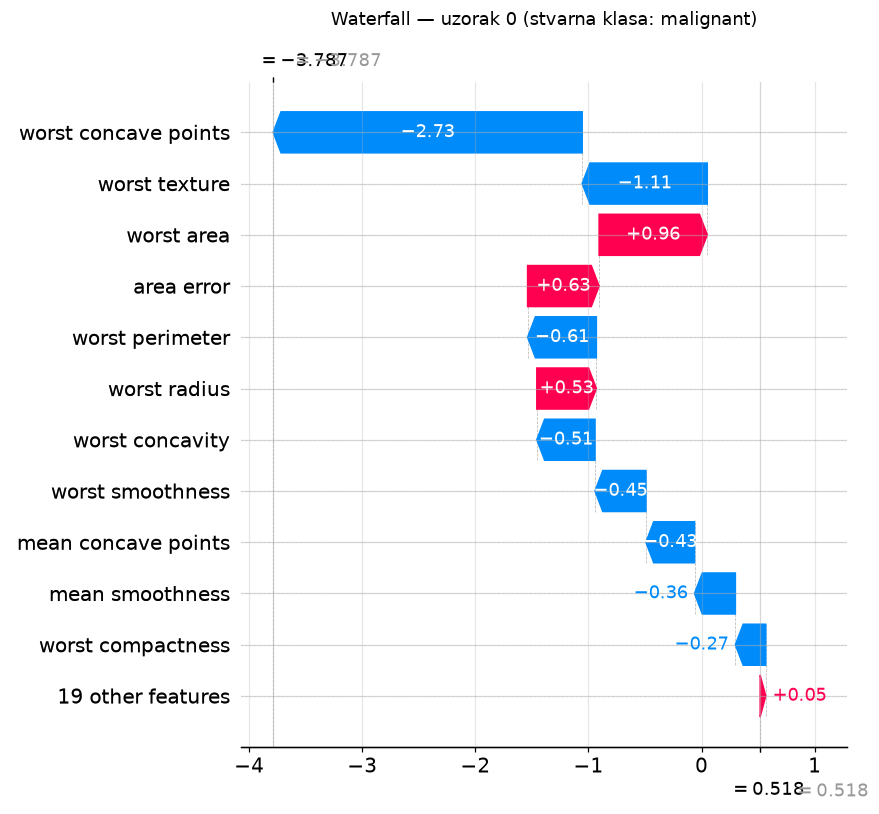

Crvene trake guraju predikciju NAVISE, plave NANIZE.
Zbir svih pomaka od bazne vrednosti daje konacnu predikciju.


In [7]:
i = 0
shap.plots._waterfall.waterfall_legacy(
    expl.expected_value, sv[i], Xte.iloc[i], max_display=12, show=False)
plt.title(f"Waterfall — uzorak {i} (stvarna klasa: {bc.target_names[yte.iloc[i]]})", pad=18)
plt.tight_layout(); plt.show()
print("Crvene trake guraju predikciju NAVISE, plave NANIZE.")
print("Zbir svih pomaka od bazne vrednosti daje konacnu predikciju.")

### Globalna važnost atributa

Dobija se **agregacijom** lokalnih SHAP vrednosti:

$$\text{Global importance}(x_i) = \mathbb{E}\big[\lvert \phi_i \rvert\big]$$

Uzmu se sve SHAP vrednosti za jedan atribut, **ignoriše se znak**, i izračuna **srednja
apsolutna** vrednost — koliko atribut u proseku „pomera" izlaz modela, bez obzira na smer.

### Beeswarm (summary) plot

| element | značenje |
|---|---|
| **Y-osa** | atributi |
| **X-osa** | SHAP vrednost (uticaj na izlaz, $\Delta\hat y$) |
| **svaka tačka** | jedna instanca (jedna predikcija) |
| **boja** | vrednost atributa (tamno = mala, svetlo = velika) |

- tačke **daleko od nule** → atribut snažno utiče
- tačke **i levo i desno** → atribut može i povećati i smanjiti predikciju

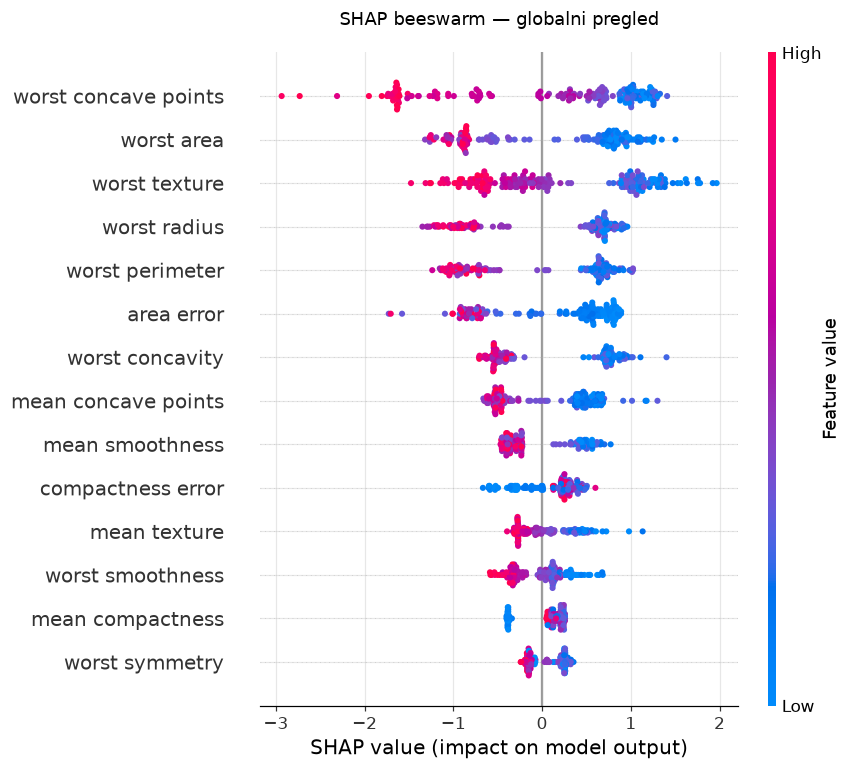

In [8]:
fig = plt.figure()
shap.summary_plot(sv, Xte, max_display=14, show=False)
plt.title("SHAP beeswarm — globalni pregled", pad=18)
plt.tight_layout(); plt.show()

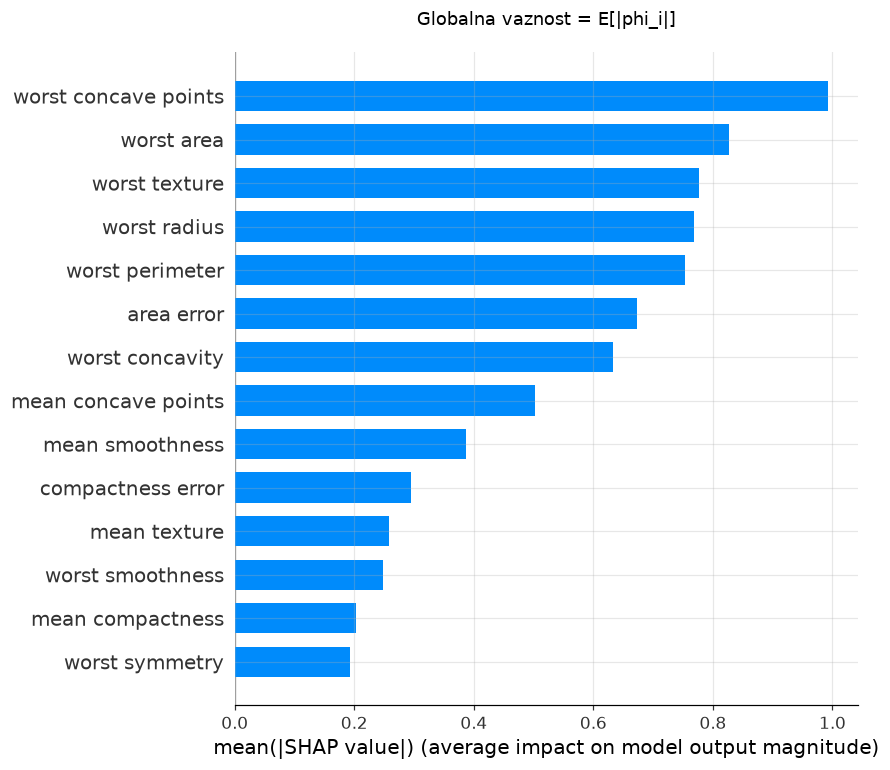

In [9]:
fig = plt.figure()
shap.summary_plot(sv, Xte, plot_type="bar", max_display=14, show=False)
plt.title("Globalna vaznost = E[|phi_i|]", pad=18)
plt.tight_layout(); plt.show()

### SHAP dependency plot

Prikazuje **kako vrednost jednog atributa utiče na predikciju**, na osnovu SHAP vrednosti.

| osa | značenje |
|---|---|
| **X** | vrednost atributa $x_i$ |
| **Y** | SHAP vrednost tog atributa — uticaj na predikciju, u **istim jedinicama kao izlaz modela** ($\Delta\hat y$) |
| **boja** | vrednost drugog atributa — otkriva **interakcije** |

Šta se sa njega vidi:
- da li veće vrednosti atributa **povećavaju ili smanjuju** predikciju
- **oblik** uticaja: linearan ili nelinearan
- potencijalne **interakcije** sa drugim atributima

> SHAP je posebno koristan jer su vrednosti na Y-osi u **istim jedinicama kao predikcija**,
> pa možemo direktno reći koliko atribut „gura" predikciju gore ili dole.

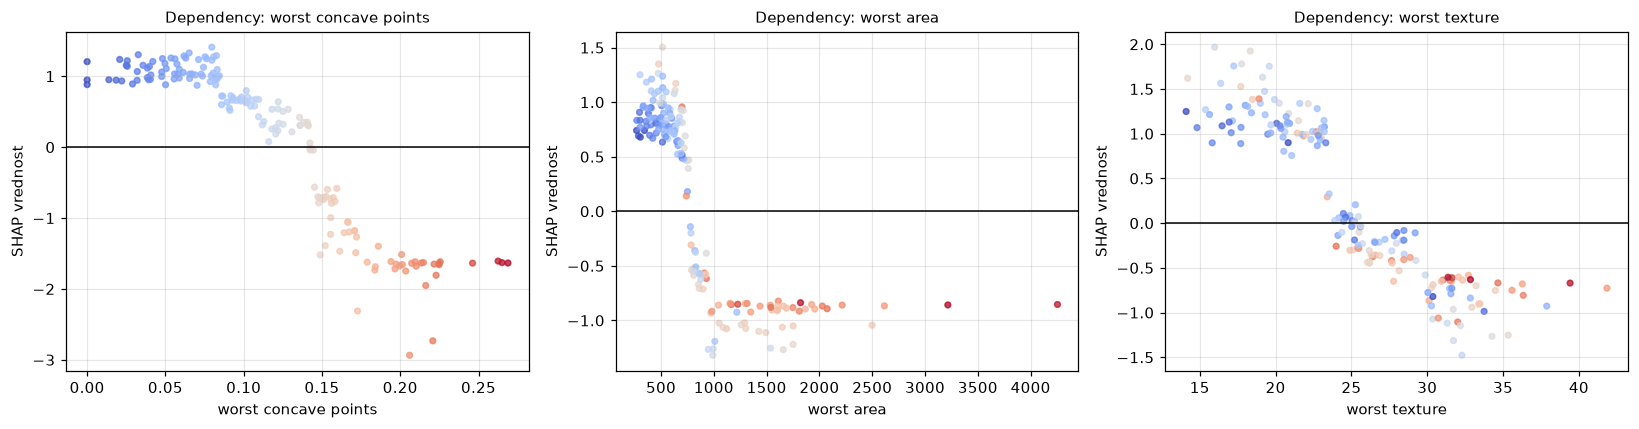

Boja je vrednost atributa 'worst concave points' — pokazuje interakcije.


In [10]:
najvazniji = X.columns[np.argsort(-np.abs(sv).mean(0))][:3]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, f in zip(ax, najvazniji):
    idx = list(X.columns).index(f)
    a.scatter(Xte[f], sv[:, idx], s=14, c=Xte[najvazniji[0]], cmap="coolwarm", alpha=0.75)
    a.axhline(0, color="k", lw=1)
    a.set_xlabel(f); a.set_ylabel("SHAP vrednost")
    a.set_title(f"Dependency: {f}", fontsize=10)
plt.tight_layout(); plt.show()
print(f"Boja je vrednost atributa '{najvazniji[0]}' — pokazuje interakcije.")

## PDP i ICE

**PDP** (Partial Dependence Plot) — prosečan efekat atributa na predikciju, preko svih
uzoraka.

**ICE** (Individual Conditional Expectation) — ista ideja, ali **jedna linija po uzorku**.
Otkriva da li se pojedinačni uzorci ponašaju drugačije od proseka — što PDP može da sakrije.

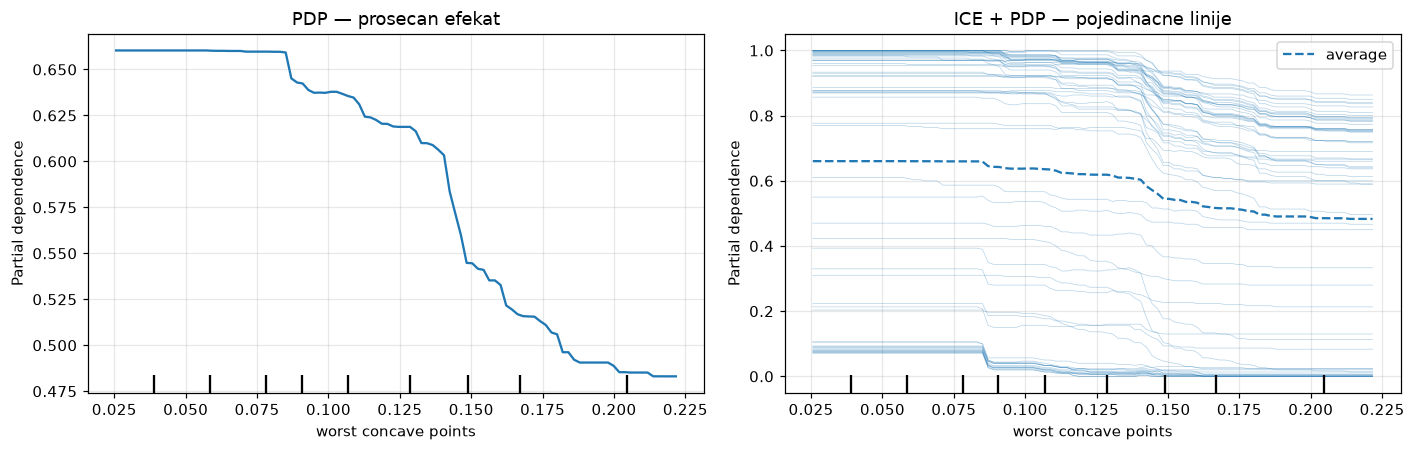

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
PartialDependenceDisplay.from_estimator(rf, Xte, [najvazniji[0]], ax=ax[0])
ax[0].set_title("PDP — prosecan efekat")
PartialDependenceDisplay.from_estimator(rf, Xte, [najvazniji[0]], kind="both",
                                        subsample=60, ax=ax[1], random_state=RS)
ax[1].set_title("ICE + PDP — pojedinacne linije")
plt.tight_layout(); plt.show()

## Kada SHAP ne pomaže — šum i overfitting

**Ako su podaci šumni, a model previše fleksibilan**, model počinje da uči šum umesto
stvarnog odnosa. Tada:

| model | kako izgleda dependency plot |
|---|---|
| **razumno fitovan** | odnos je gladak, stabilan, lako uočljiv |
| **overfitovan** | plot je **rasut**, pun tačaka bez jasnog obrasca |
| **underfitovan** | SHAP vrednosti su **„spljoštene"**, nema jasnog obrasca |

> **SHAP objašnjava model, ne „popravlja" njegove greške.**
> SHAP ne može biti bolji od modela koji objašnjava — ako je model overfitovan, SHAP će
> **verno objasniti loš model** i reflektovaće šum, a ne signal.

**Najinformativniji SHAP plotovi dolaze iz dobro regularizovanog modela.**

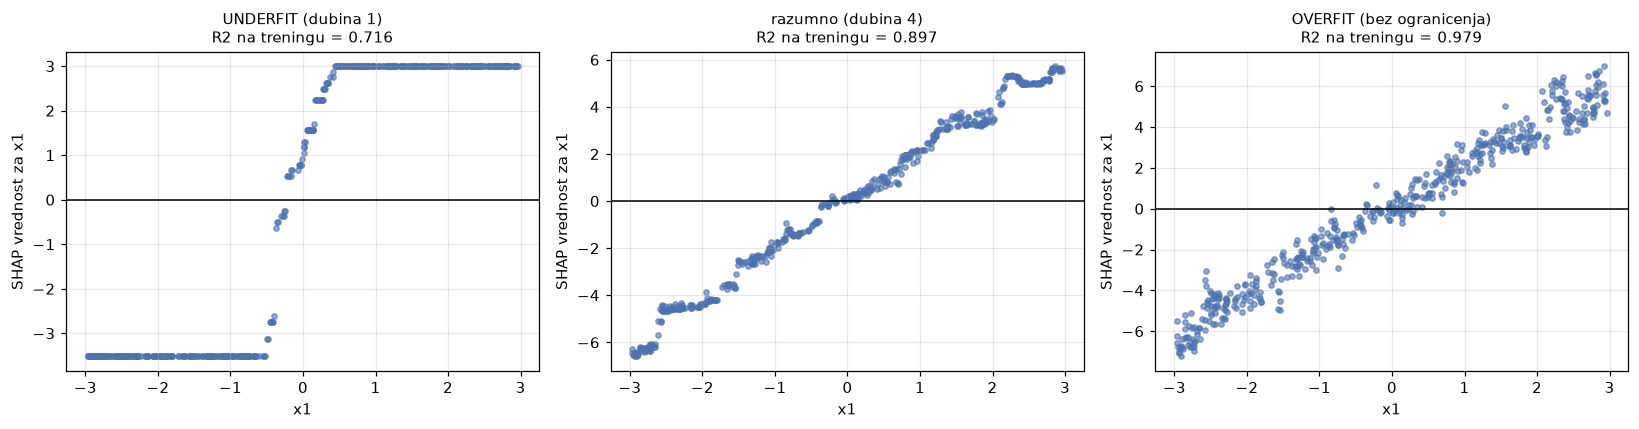

Levo: spljosteno — model nije naucio odnos.
Sredina: gladak linearan odnos — tacno kako podaci i jesu generisani.
Desno: rasuto — model uci sum, pa SHAP verno prikazuje taj sum.


In [12]:
rng = np.random.RandomState(RS)
n = 500
x1 = rng.uniform(-3, 3, n)
sum_v = rng.normal(0, 1.4, n)
yv = 2 * x1 + sum_v                                # prava veza je LINEARNA
Xv = pd.DataFrame({"x1": x1, "x2": rng.normal(0, 1, n)})

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (ime, m) in zip(ax, [
        ("UNDERFIT (dubina 1)", RandomForestRegressor(n_estimators=50, max_depth=1, random_state=RS)),
        ("razumno (dubina 4)", RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RS)),
        ("OVERFIT (bez ogranicenja)", RandomForestRegressor(n_estimators=200, random_state=RS))]):
    m.fit(Xv, yv)
    s = shap.TreeExplainer(m).shap_values(Xv)
    a.scatter(Xv.x1, s[:, 0], s=12, color="#4C72B0", alpha=0.6)
    a.axhline(0, color="k", lw=1)
    a.set_xlabel("x1"); a.set_ylabel("SHAP vrednost za x1")
    a.set_title(f"{ime}\nR2 na treningu = {m.score(Xv, yv):.3f}", fontsize=10)
plt.tight_layout(); plt.show()
print("Levo: spljosteno — model nije naucio odnos.")
print("Sredina: gladak linearan odnos — tacno kako podaci i jesu generisani.")
print("Desno: rasuto — model uci sum, pa SHAP verno prikazuje taj sum.")

## Redundantni (korelisani) atributi

Kada su atributi **međusobno korelisani**, više njih nosi sličnu ili delimično istu
informaciju.

| | bez korelacije | sa korelacijom |
|---|---|---|
| raspored tačaka | ravnomeran | pojavljuju se **grupisanja / segmenti** |
| boja (drugi atribut) | ne formira strukturu | uvodi **vidljivu strukturu** |

> Kada su atributi korelisani, SHAP vrednosti reflektuju **zajednički doprinos**, a
> dependency plot otkriva **skrivene interakcije**.

Praktična posledica: doprinos se „deli" između korelisanih atributa, pa nijedan ne izgleda
tako važan koliko zaista jeste. To treba imati u vidu pri tumačenju.

In [13]:
n = 600
a1 = rng.normal(0, 1, n)
a2 = 0.95 * a1 + rng.normal(0, 0.3, n)          # skoro kopija a1
a3 = rng.normal(0, 1, n)
Xk = pd.DataFrame({"a1": a1, "a2_kopija_a1": a2, "a3_nezavisan": a3})
yk = (3 * a1 + 2 * a3 + rng.normal(0, 0.5, n) > 0).astype(int)

mk = XGBClassifier(n_estimators=200, max_depth=3, eval_metric="logloss",
                   random_state=RS).fit(Xk, yk)
sk = shap.TreeExplainer(mk).shap_values(Xk)

print(f"Korelacija a1 i a2: {np.corrcoef(a1, a2)[0,1]:.3f}\n")
print("Prosecna |SHAP| vrednost:")
for i, c in enumerate(Xk.columns):
    print(f"   {c:<16} {np.abs(sk[:, i]).mean():.4f}")
print("\n-> a1 i a2 nose ISTU informaciju, pa model deli doprinos izmedju njih.")
print("   Pojedinacno izgledaju manje vazno nego sto jesu.")

Korelacija a1 i a2: 0.956

Prosecna |SHAP| vrednost:
   a1               5.2540
   a2_kopija_a1     1.0476
   a3_nezavisan     4.2092

-> a1 i a2 nose ISTU informaciju, pa model deli doprinos izmedju njih.
   Pojedinacno izgledaju manje vazno nego sto jesu.


## LIME — alternativa SHAP-u

**LIME** (Local Interpretable Model-agnostic Explanations) objašnjava jednu predikciju
tako što oko nje napravi mnogo perturbovanih uzoraka i na njima fituje **jednostavan
lokalni model** (npr. linearnu regresiju).

| | **SHAP** | **LIME** |
|---|---|---|
| osnova | teorija igara | lokalna aproksimacija |
| garancije | **fer raspodela**, efikasnost, konzistentnost | nema teorijskih garancija |
| brzina | sporiji (osim TreeSHAP) | brži |
| stabilnost | deterministički | može varirati između pokretanja |

U praksi se SHAP češće koristi jer ima teorijsku osnovu i konzistentne rezultate.

## Sažetak

| metoda | tip | šta daje |
|---|---|---|
| koeficijenti | model-specifična | smer i jačina linearnog uticaja |
| struktura stabla | model-specifična | čitljiva if-then pravila |
| `feature_importances_` | model-specifična | globalna važnost kod stabala |
| **permutaciona važnost** | model-agnostička | globalna važnost za bilo koji model |
| **SHAP** | model-agnostička | **lokalno + globalno**, aditivno i fer |
| **PDP / ICE** | model-agnostička | oblik zavisnosti od atributa |
| **LIME** | model-agnostička | brzo lokalno objašnjenje |

**Ključno za odbranu projekta:**
1. SHAP objašnjava **model**, ne stvarnost — korelacija nije uzročnost
2. Loš model daje loše objašnjenje, ma koliko lepo izgledalo
3. Kod korelisanih atributa doprinos se deli, pa važnost može biti potcenjena